В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn import preprocessing

import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [6]:
cars_df = pd.read_csv('cars.csv')
cars_df.head(5)

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [9]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
#?pd.DataFrame.info

In [11]:
cars_df.info()
cars_df.dtypes
cars_df['Transmission'].nunique()
for col in ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type']:
    print(col, cars_df[col].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB
Brand 11
Model 58
Fuel_Type 2
Transmission 2
Owner_Type 3


В наборі даних 8 числових і 5 категоріальних колонок, з них:
- 1 бінарна (Transmission)
- 3 мультикатегоріальні без порядку (Brand, Model, Fuel_Type)
- 1 колонка з впорядкованими категоріями (Owner_Type)

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [16]:

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

X = cars_df[["Year", "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats"]]
y = cars_df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

model = train_model(X_train, y_train)

# Train RMSE
y_train_pred = model.predict(X_train)
rmse_train = root_mean_squared_error(y_train, y_train_pred)
print('Train RMSE:', rmse_train)

# Test RMSE
y_test_pred = model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, y_test_pred)
print('Test RMSE:', rmse_test)

Train RMSE: 516330.6226410494
Test RMSE: 421183.67770851153


Train RMSE ≈ 516k і Test RMSE ≈ 421k показують, що модель має досить велику похибку на обох вибірках.

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

Fuel_Type unique values: ['Petrol' 'Diesel']
Transmission unique values: ['Manual' 'Automatic']

Fuel_Type counts:
Fuel_Type
Petrol    52
Diesel    48
Name: count, dtype: int64

Transmission counts:
Transmission
Automatic    57
Manual       43
Name: count, dtype: int64


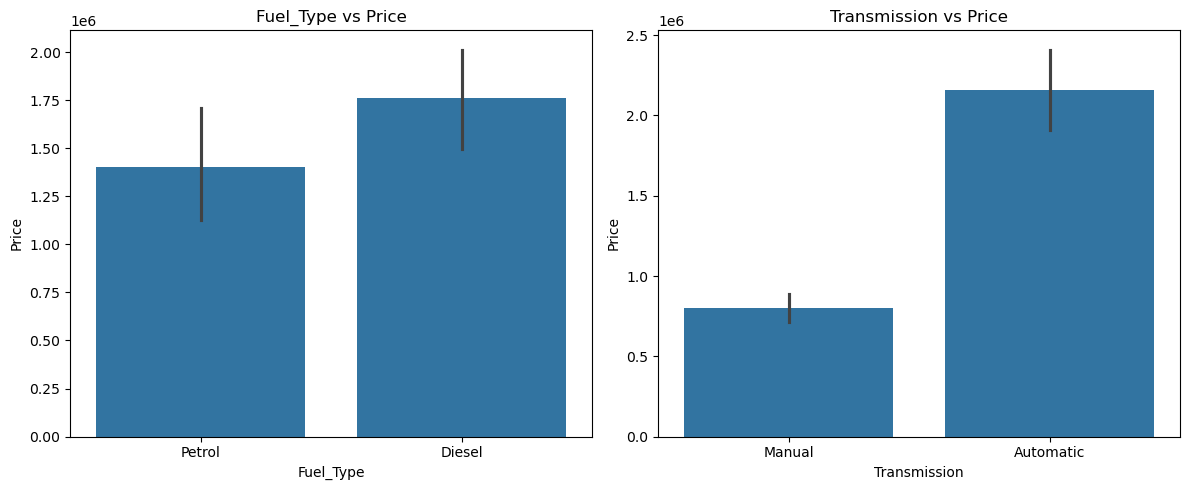

In [21]:
# 1

# Унікальні значення
print("Fuel_Type unique values:", cars_df['Fuel_Type'].unique())
print("Transmission unique values:", cars_df['Transmission'].unique())

# Частоти (корисно для перевірки, хто має бути 1)
print("\nFuel_Type counts:")
print(cars_df['Fuel_Type'].value_counts())

print("\nTransmission counts:")
print(cars_df['Transmission'].value_counts())

# Мультиплот
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=cars_df, x='Fuel_Type', y='Price', ax=axes[0])
axes[0].set_title('Fuel_Type vs Price')

sns.barplot(data=cars_df, x='Transmission', y='Price', ax=axes[1])
axes[1].set_title('Transmission vs Price')

plt.tight_layout()
plt.show()

In [23]:
Fuel_Type_codes = {'Petrol': 0, 'Diesel': 1}
cars_df['Fuel_Type_code'] = cars_df.Fuel_Type.map(Fuel_Type_codes)

Transmission_codes = {'Manual': 0, 'Automatic': 1}
cars_df['Transmission_code'] = cars_df.Transmission.map(Transmission_codes)

cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Fuel_Type_code,Transmission_code
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000,0,0
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000,0,1
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000,0,1
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000,1,0
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000,1,1


In [25]:
X = cars_df[[
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Fuel_Type_code",
    "Transmission_code"
]]

y = cars_df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

model = train_model(X_train, y_train)

# Train RMSE
y_train_pred = model.predict(X_train)
rmse_train = root_mean_squared_error(y_train, y_train_pred)
print('Train RMSE:', rmse_train)

# Test RMSE
y_test_pred = model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, y_test_pred)
print('Test RMSE:', rmse_test)

Train RMSE: 433008.27370790875
Test RMSE: 277481.8931339636


Після додавання закодованих категоріальних змінних якість моделі покращилась: RMSE на train і test зменшився, що свідчить про кращу здатність моделі пояснювати дані

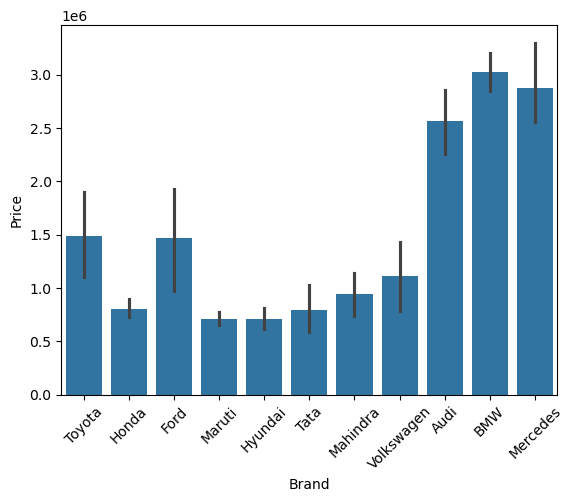

In [28]:
# 2
sns.barplot(data=cars_df, x='Brand', y='Price')
plt.xticks(rotation=45)
plt.show()

In [30]:
#2

X = cars_df[[
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Fuel_Type_code",
    "Transmission_code",
    "Brand"
]]

y = cars_df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

# encoder
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# fit ONLY on train
enc.fit(X_train[['Brand']])

# transform
brand_train = enc.transform(X_train[['Brand']])
brand_test = enc.transform(X_test[['Brand']])

# column names
brand_cols = enc.get_feature_names_out(['Brand'])

# DataFrame з one-hot
brand_train_df = pd.DataFrame(brand_train, columns=brand_cols, index=X_train.index)
brand_test_df = pd.DataFrame(brand_test, columns=brand_cols, index=X_test.index)

# прибираємо Brand і додаємо закодовані
X_train = X_train.drop('Brand', axis=1).join(brand_train_df)
X_test = X_test.drop('Brand', axis=1).join(brand_test_df)

# модель
model = LinearRegression()
model.fit(X_train, y_train)

# оцінка
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))

Train RMSE: 211844.61229981098
Test RMSE: 252594.04100513546


помилка на train і test близькі. Після кодування Brand якість суттєво покращилась

In [33]:
from sklearn.preprocessing import OrdinalEncoder

X = cars_df[[
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Fuel_Type_code",
    "Transmission_code",
    "Brand",
    "Owner_Type"
]]
y = cars_df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)
ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [36]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Brand,Owner_Type,Owner_Type_Codes
83,2019,22000,18,1498,148,5,0,1,Volkswagen,Second,1.0
55,2018,28000,17,1968,187,5,1,1,Audi,First,0.0
26,2018,28000,15,1984,241,5,0,1,Audi,First,0.0
54,2017,32000,18,1598,103,5,0,0,Volkswagen,Second,1.0
19,2017,26000,12,1991,241,5,0,1,Mercedes,Second,1.0


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Brand,Owner_Type,Owner_Type_Codes
17,2016,38000,15,1395,148,5,0,1,Audi,Second,1.0
41,2019,26000,20,1086,68,5,0,0,Hyundai,Third,2.0
92,2017,32000,18,1598,103,5,0,0,Volkswagen,Second,1.0
14,2020,18000,19,1462,103,7,0,0,Maruti,First,0.0
68,2019,26000,20,1194,94,5,0,0,Ford,Third,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Owner_Type_Codes,Price
Year,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,-0.248515,-0.200603,-0.014499,-0.233769
Kilometers_Driven,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,0.332351,-0.066491,-0.001772,-0.083951
Mileage,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,0.070112,-0.399164,0.026624,-0.638404
Engine,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,0.174455,0.456296,-0.196106,0.710561
Power,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,-0.076357,0.586910,-0.204309,0.849137
Seats,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,0.412468,-0.070099,-0.043849,0.000979
Fuel_Type_code,-0.248515,0.332351,0.070112,0.174455,-0.076357,0.412468,1.000000,0.005775,-0.281122,0.110782
Transmission_code,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,0.005775,1.000000,0.005886,0.680731
Owner_Type_Codes,-0.014499,-0.001772,0.026624,-0.196106,-0.204309,-0.043849,-0.281122,0.005886,1.000000,-0.265537
Price,-0.233769,-0.083951,-0.638404,0.710561,0.849137,0.000979,0.110782,0.680731,-0.265537,1.000000


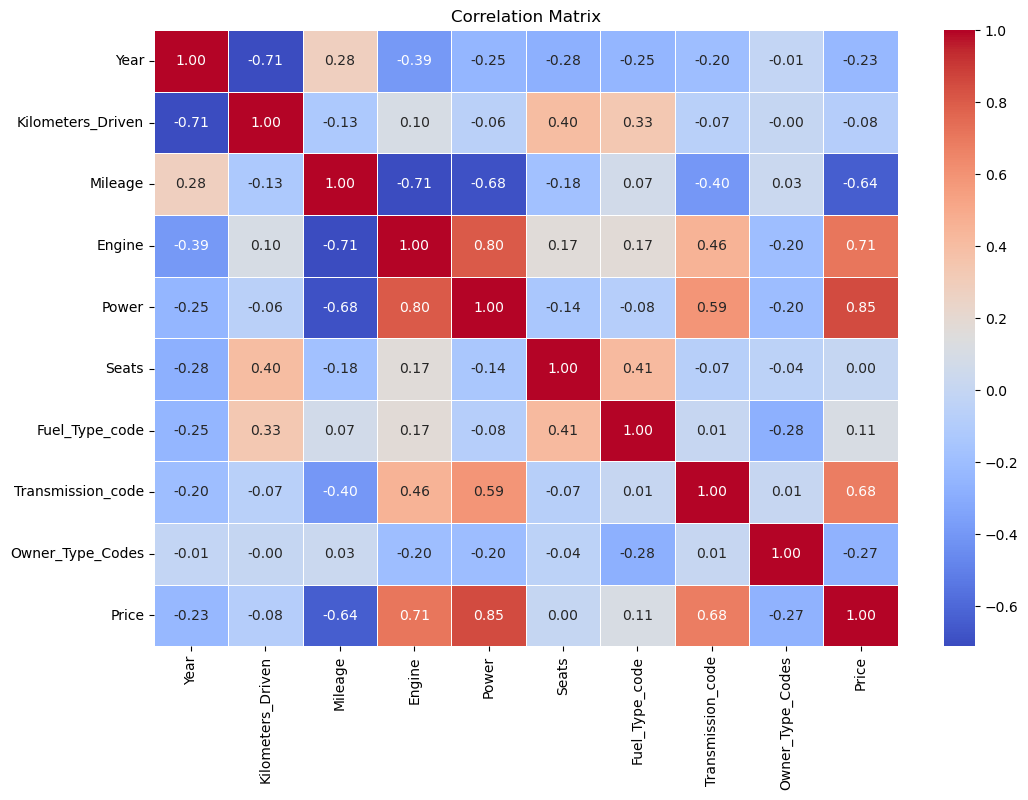

In [39]:
# залишаємо тільки числові колонки
X_train = X_train.select_dtypes(exclude=['object'])

# об'єднуємо з цільовою змінною
df_corr = pd.concat([X_train, y_train], axis=1)

# кореляція
corr_matrix = df_corr.corr(numeric_only=True)
display(corr_matrix)
# графік
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

Найсильніший позитивний зв’язок із ціною мають змінні Power (0.85), Engine (0.71) та Transmission_code (0.68), що свідчить про те, що потужніші автомобілі з більшим об’ємом двигуна та автоматичною коробкою передач зазвичай коштують дорожче. Найсильніший негативний зв’язок спостерігається у Mileage (-0.64), тобто з ростом пробігу ціна автомобіля знижується. Інші змінні мають слабку або помірну кореляцію з ціною: Seats майже не впливає (0.00), Fuel_Type_code має слабкий позитивний зв’язок (0.11), Owner_Type_Codes — слабкий негативний (-0.27), а Kilometers_Driven також має дуже слабкий негативний зв’язок (-0.08). Загалом можна зробити висновок, що найбільший вплив на ціну мають технічні характеристики автомобіля, тоді як експлуатаційні та категоріальні ознаки впливають значно слабше.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [43]:
# 1

X = cars_df.drop('Price', axis=1)
y = cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

# тільки числові
X_train_num = X_train.select_dtypes(exclude=['object'])
X_test_num = X_test.select_dtypes(exclude=['object'])

# модель
lin_reg = LinearRegression()
lin_reg.fit(X_train_num, y_train)

# 2,  predictions and RMSE
pred_train = lin_reg.predict(X_train_num)
pred_test = lin_reg.predict(X_test_num)


print("Train RMSE:", root_mean_squared_error(y_train, pred_train))
print("Test RMSE:", root_mean_squared_error(y_test, pred_test))

Train RMSE: 432295.8023752393
Test RMSE: 276678.5341283451


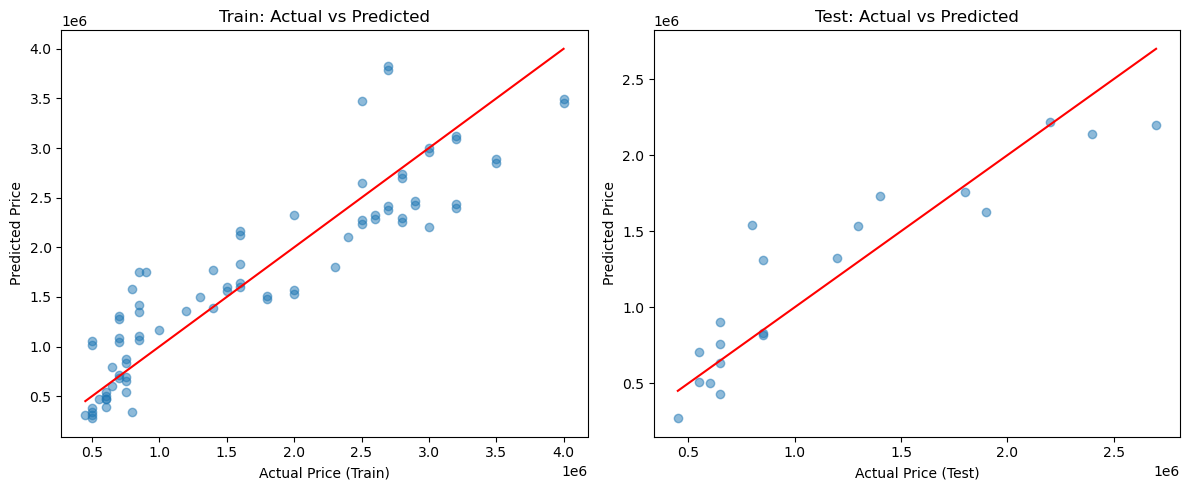

In [45]:
# 3

plt.figure(figsize=(12, 5))

# TRAIN
plt.subplot(1, 2, 1)
plt.scatter(y_train, pred_train, alpha=0.5)
plt.xlabel("Actual Price (Train)")
plt.ylabel("Predicted Price")
plt.title("Train: Actual vs Predicted")

# ідеальна лінія
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red')

# TEST
plt.subplot(1, 2, 2)
plt.scatter(y_test, pred_test, alpha=0.5)
plt.xlabel("Actual Price (Test)")
plt.ylabel("Predicted Price")
plt.title("Test: Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.tight_layout()
plt.show()

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [50]:
# 1

scaler = StandardScaler()

# fit тільки на train
X_train_scaled = scaler.fit_transform(X_train_num)

# transform test
X_test_scaled = scaler.transform(X_test_num)


X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_num.columns,
    index=X_train_num.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_num.columns,
    index=X_test_num.index
)

# 2 

# модель
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# коефіцієнти
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lin_reg.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

coef_df

,Feature,Coefficient
5,Power,723471.807582
8,Transmission_code,256055.000754
7,Fuel_Type_code,216501.995113
2,Kilometers_Driven,-178355.625244
3,Mileage,-169302.835136
4,Engine,-141618.928655
6,Seats,77130.053615
1,Year,-73959.868736
0,Car_ID,28093.304687


Найбільший вплив на ціну має Power (позитивний), а також Transmission_code і Fuel_Type_code — вони підвищують ціну. Негативний вплив мають Kilometers_Driven і Mileage, тобто більший пробіг зменшує вартість. Коефіцієнт Engine вийшов від’ємним, що, ймовірно, пов’язано з кореляцією з Power. Car_ID не має змісту і не повинен використовуватись у моделі.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [55]:
X_train_sm = sm.add_constant(X_train_scaled)
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     36.71
Date:                Sun, 03 May 2026   Prob (F-statistic):           4.38e-23
Time:                        08:32:34   Log-Likelihood:                -1151.7
No. Observations:                  80   AIC:                             2323.
Df Residuals:                      70   BIC:                             2347.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   5.17e+0

In [57]:
p_values = model.pvalues

significant = p_values[p_values < 0.05]
print(significant)

const                5.621414e-44
Mileage              4.740689e-02
Power                2.126991e-08
Fuel_Type_code       1.033413e-03
Transmission_code    2.414776e-04
dtype: float64


Статистично значущими ознаками (p-value < 0.05) є: Mileage, Power, Fuel_Type_code, Transmission_code.

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [62]:
# вибираємо тільки значущі ознаки
features = ['Mileage', 'Power', 'Fuel_Type_code', 'Transmission_code']

X_train_sig = X_train_scaled[features]

# додаємо константу
X_train_sig = sm.add_constant(X_train_sig)

# модель
model_sig = sm.OLS(y_train, X_train_sig).fit()

# звіт
print(model_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     77.42
Date:                Sun, 03 May 2026   Prob (F-statistic):           7.36e-26
Time:                        08:32:37   Log-Likelihood:                -1156.0
No. Observations:                  80   AIC:                             2322.
Df Residuals:                      75   BIC:                             2334.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   5.27e+0

Модель залишилась якісною після відбору ознак, а основний вплив на ціну мають Power, тип трансмісії та тип палива. Mileage в цій моделі не є статистично значущим, ймовірно через кореляцію з іншими змінними.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?